In [3]:
from google.colab import files
uploaded=files.upload()
print(uploaded)

Saving train.csv to train.csv
{'train.csv': b'PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked\r\n1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,,S\r\n2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C\r\n3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,,S\r\n4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S\r\n5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,,S\r\n6,0,3,"Moran, Mr. James",male,,0,0,330877,8.4583,,Q\r\n7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S\r\n8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,,S\r\n9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,,S\r\n10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,,C\r\n11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4,1,1,PP 9549,16.7,G6,S\r\n12,1,1,"Bonnell, Miss. Elizabeth",female

In [1]:
!pip install pandas
import pandas as pd
import matplotlib.pyplot as plt

# Titanic EDA — Exploratory Data Analysis

Analysing survival patterns in the Titanic dataset using Pandas and Matplotlib.


**Loading Dataset**

In [4]:
titanic_ds=pd.read_csv('train.csv')
titanic_ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Overview**

In [5]:
#shape of dataset
titanic_ds.shape

(891, 12)

In [6]:
#information about dataset
titanic_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
#dtypes of each column
titanic_ds.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [8]:
#null value count of each column
titanic_ds.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [9]:
#Basic statistics with describe()
titanic_ds.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


**Cleaning**

In [10]:
#filling age column with medain
titanic_ds['Age'].fillna(titanic_ds['Age'].median(),inplace=True)
#checking whether age col has null vals or not
titanic_ds['Age'].isnull().sum()

/tmp/ipykernel_1294/680632269.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_ds['Age'].fillna(titanic_ds['Age'].median(),inplace=True)


np.int64(0)

In [11]:
#Drop Cabin column
titanic_ds.drop('Cabin',axis=1,inplace=True)
titanic_ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [12]:
#Drop duplicates
titanic_ds.drop_duplicates(inplace=True)

In [13]:
#Convert Sex to 0/1
titanic_ds['Sex']=titanic_ds['Sex'].apply(lambda x:0 if x=='male' else 1)
titanic_ds.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,S


In [14]:
titanic_ds['Embarked']=titanic_ds['Embarked'].fillna(titanic_ds['Embarked'].mode()[0])


In [15]:
#Verify no nulls remain
titanic_ds.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


**Analysis**

**What was the overall survival rate?**

In [16]:
titanic_ds['Survived'].value_counts()


,count
Survived,
0,549
1,342


In [33]:
survived_class=["Survived","Not survived"]
count=[round((titanic_ds['Survived'].value_counts()[1]/891)*100,1),round((titanic_ds['Survived'].value_counts()[0]/891)*100,1)]

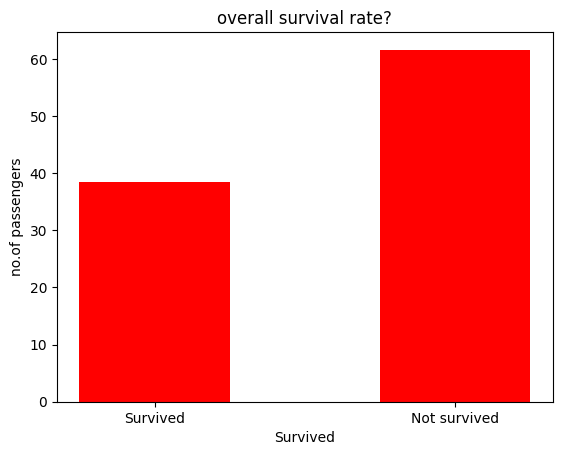

In [34]:
plt.bar(survived_class,count,color='red',width=0.5)
plt.title("overall survival rate?")
plt.xlabel("Survived")
plt.ylabel('no.of passengers')
plt.show()

from the above analysis ,we can say that  only 38% passengers survived remaining 62 % passengers died i.e. out of 891 passengers 342 survived and 549 are died

**Did passenger class (1st/2nd/3rd) affect survival?**

In [19]:
class_count=[]
groupby_cls=titanic_ds.groupby('Pclass')
for cls,dt in groupby_cls:
   print(dt['Survived'].value_counts()[1])
   class_count.append(dt['Survived'].value_counts()[1])


136
87
119


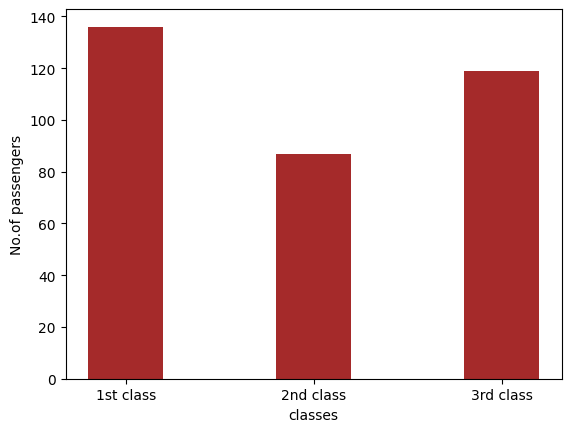

In [ ]:
labels=["1st class","2nd class","3rd class"]
plt.bar(labels,class_count,color='brown',width=0.4)
plt.xlabel("classes")
plt.ylabel('No.of passengers')
plt.show()

This shows that 136 paasengers survived who are in 1st class
87 passengers survived who are in 2nd class
119 passengers survived who are in 3rd class

By the above ,we can say that 1st class passengers has highest survival rate

**Did gender affect survival?**

In [20]:
#0-male
#1-female
survived_people=titanic_ds[titanic_ds['Survived']==1]
survived_people['Sex'].value_counts()

,count
Sex,
1,233
0,109


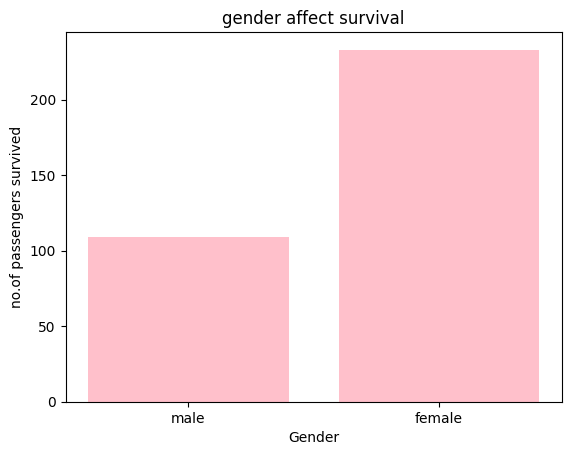

In [21]:
gender_count=[survived_people['Sex'].value_counts()[0],survived_people['Sex'].value_counts()[1]]
sex=["male","female"]
plt.bar(sex,gender_count,color='pink')
plt.xlabel("Gender")
plt.ylabel("no.of passengers survived")
plt.title("gender affect survival")
plt.show()

By the above analysis ,we can say that female survival rate higher than  male surival rate

**What age group had the highest survival rate?**

In [22]:
#get the ages of survived people
survived_people=titanic_ds[titanic_ds['Survived']==1]
survived_per_age=survived_people['Age']
survived_per_age.head()


,Age
1,38.0
2,26.0
3,35.0
8,27.0
9,14.0


(array([130., 196.,  16.]), array([ 0.42      , 26.94666667, 53.47333333, 80.        ]), <BarContainer object of 3 artists>)


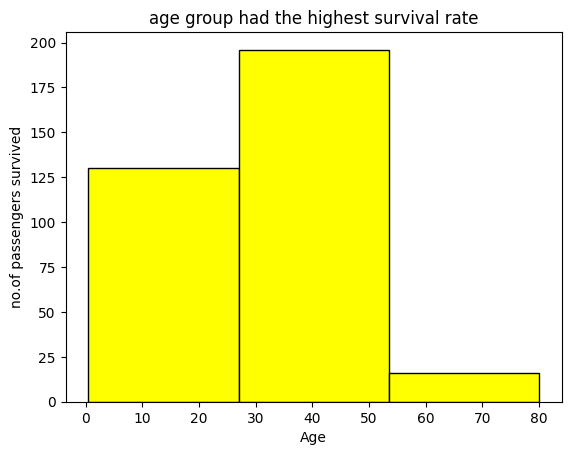

In [23]:
bins=plt.hist(survived_per_age,color='yellow',bins=3,edgecolor='black')
plt.xlabel("Age")
plt.ylabel("no.of passengers survived")
plt.title("age group had the highest survival rate")
print(bins)
plt.show()

By the above histogram ,we can say that 26-53 age group has highest survival rate

**Which port of embarkation had the highest survival count?**

In [25]:
survived_people['Embarked'].value_counts()

,count
Embarked,
S,219
C,93
Q,30


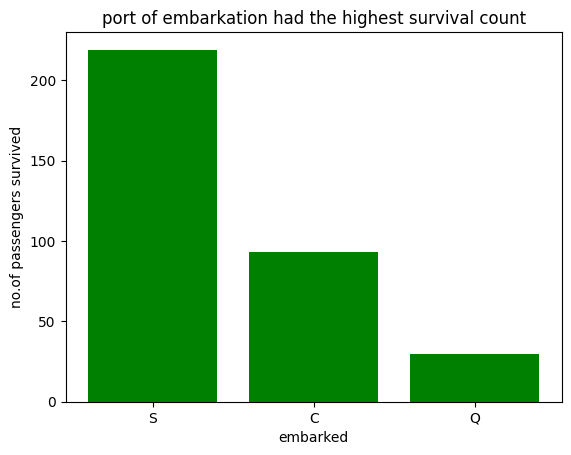

In [26]:
import numpy as np
embarked=np.array(titanic_ds['Embarked'].unique())
embarked_counts=np.array([survived_people['Embarked'].value_counts()['S'],survived_people['Embarked'].value_counts()['C'],survived_people['Embarked'].value_counts()['Q']])
plt.bar(embarked,embarked_counts,color='green')
plt.xlabel("embarked")
plt.ylabel("no.of passengers survived")
plt.title("port of embarkation had the highest survival count")
plt.show()

by the above bargraph ,we can understand that "s" embark has highest survival rate

**Which port of embarkation had the highest survival rate?**

In [42]:
titanic_ds.groupby("Embarked")['Survived'].mean()

,Survived
Embarked,
C,0.553571
Q,0.389610
S,0.339009


**Did fare paid correlate with survival?**

In [27]:
final=titanic_ds.groupby("Survived")["Fare"].mean()
final

,Fare
Survived,
0,22.117887
1,48.395408


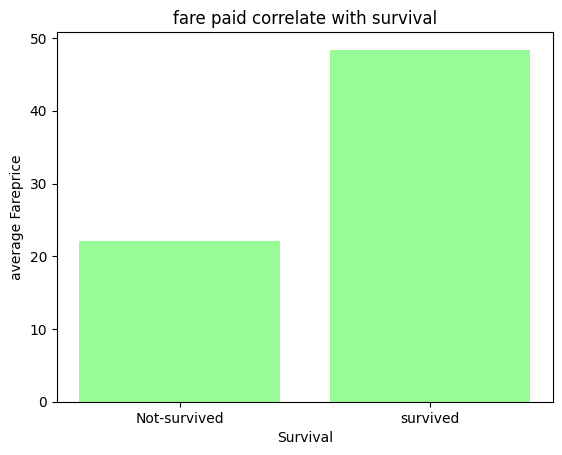

In [28]:
labels=["Not-survived","survived"]
fareprice=[final[0],final[1]]
plt.bar(labels,fareprice,color='palegreen')
plt.xlabel("Survival")
plt.ylabel("average Fareprice")
plt.title("fare paid correlate with survival")
plt.show()

by the above ,we can say that people who survived paid higher fareprice than the not-survived people

**Key Findings**


*   38% of passengers survived overall
*   1st class passengers had the highest survival rate
*   Females survived at ~74% vs males at ~19%
*   Age group 26–53 had the highest survival count
*   Survivors paid on average higher fares than non-survivors
*   Southampton (S) port had the highest survival count (219) but Cherbourg(C)  
  had the highest survival rate at 55%




